In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/airbnb.csv")
df.head(1)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228.0,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.68371,-73.96461,Private room,55,...,20-12-2015,0.03,1.0,0.0,0.0,No License,5,1,1.0,Not specified


**Summary of Dataset :**

This dataset contains information about Airbnb listings in New York City.

***Columns: -***

**"id"** : integer, Unique ID of each listing

**"name"** : String, title of the Airbnb listings

**"host_id"**: integer, unique ID of the host

**"host_name"** : String, name of the host

**"neighbourhood_group"** : Categorical, major area in NYC

**"neighbourhood"** : Categorical, specific local area within the group

**"latitude"** : float, geographical latitude of listings

**"longitude"** : float, geographical longitude

**"room_type" **: Categorical, type of rooms

**"price"** : integer, price per night in USD

**"minimum_nights"** : integer, minimum number of nights required to book

**"number_of_reviews"** : integer, total reviews received

**"last_review"** : date, date of last review

**"reviews_per_month"** : float, average number of reviews per month

**"calculated_host_listings_count"** : integer, number of listings owned by the host

**"availability_365"** : integer, number of days available in a year

**"license"** : Categorical, indicates whether the listing has a legal rental license

**"rating"** : float with text values, average rating of the listings

**"bedrooms"** : mixed, number of bedrooms in the listing

**"beds"** : integer, total number of beds available

**"baths"** : mixed, number of bathrooms

In [ ]:
df.shape

(10193, 22)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10193 entries, 0 to 10192
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10193 non-null  float64
 1   name                            10193 non-null  object 
 2   host_id                         10193 non-null  int64  
 3   host_name                       10193 non-null  object 
 4   neighbourhood_group             10193 non-null  object 
 5   neighbourhood                   10193 non-null  object 
 6   latitude                        10193 non-null  float64
 7   longitude                       10193 non-null  float64
 8   room_type                       10193 non-null  object 
 9   price                           10193 non-null  int64  
 10  minimum_nights                  10193 non-null  int64  
 11  number_of_reviews               10193 non-null  int64  
 12  last_review                     

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
#checking duplicate values
df.duplicated().sum()

np.int64(5)

In [ ]:
#drop null values
df.dropna(inplace=True)

In [ ]:
#checking shape of dataset
df.shape

(10192, 22)

In [ ]:
# replaced studio with 0 for better evaluation
df['bedrooms'] = df['bedrooms'].str.replace('Studio', '0').astype(int)

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,bedrooms,beds
count,1.019200e+04,1.019200e+04,10192.000000,10192.000000,10192.000000,10192.000000,10192.000000,10192.000000,10192.000000,10192.000000,10192.000000,10192.000000,10192.000000
mean,2.953375e+17,1.755243e+08,40.727150,-73.942528,203.978709,29.116170,42.280907,1.238769,18.013638,201.838893,10.489403,1.319761,1.726845
std,3.879782e+17,1.728711e+08,0.059480,0.057616,1437.100081,39.725563,75.718892,1.945772,65.161104,136.005272,18.590666,0.875472,1.175651
min,5.121000e+03,1.678000e+03,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.757044e+07,1.961210e+07,40.685317,-73.981392,80.000000,30.000000,4.000000,0.210000,1.000000,82.000000,1.000000,1.000000,1.000000
50%,4.968083e+07,1.101595e+08,40.722775,-73.950322,126.000000,30.000000,14.000000,0.640000,2.000000,207.000000,3.000000,1.000000,1.000000
75%,7.100000e+17,3.132574e+08,40.762802,-73.920682,200.000000,30.000000,48.000000,1.770000,6.000000,350.000000,15.000000,2.000000,2.000000
max,1.050000e+18,5.489914e+08,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,68.930000,713.000000,365.000000,733.000000,15.000000,21.000000


**Price Analysis**

In [ ]:
# mean vs median
mean = df['price'].mean()
median = df['price'].median()
print(mean)
print(median)
# there may be some outliers which affecting mean

203.9787087912088
126.0


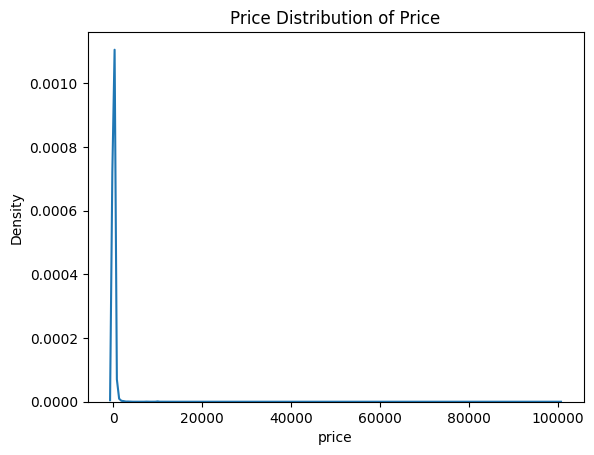

Skewness of Price Column: 65.96488306893762


In [ ]:
# distribution of price
sns.kdeplot(df['price'])
plt.title('Price Distribution of Price')
plt.show()

# skewness of df['price']
print(f"Skewness of Price Column: {df['price'].skew()}")

# price distribution is right skewed not normally distributed

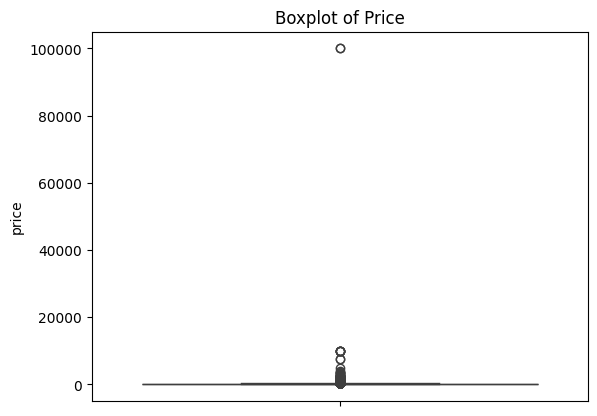

In [ ]:
# to detect outliers in price
sns.boxplot(df['price'])
plt.title('Boxplot of Price')
plt.show()
# there are extreme outliers present in price

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'] .quantile(0.75)
IQR = Q1 - Q3
print(IQR)

-120.0


In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

260.0
20.0


In [ ]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]['price']
print(outliers)

0         55
1        144
2        187
3        120
4         85
        ... 
10187     55
10188    118
10189     93
10190    800
10191     92
Name: price, Length: 10192, dtype: int64


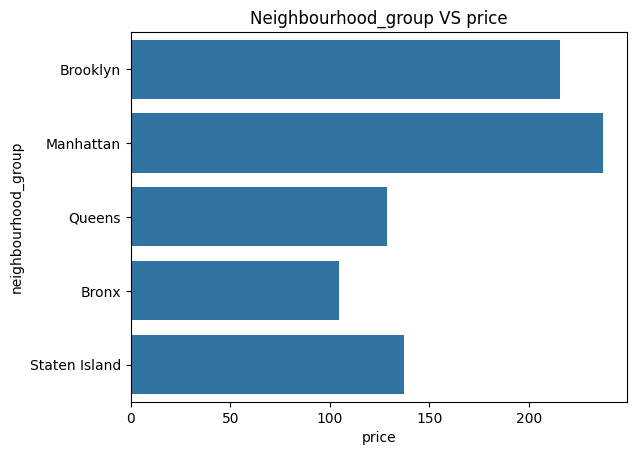

In [ ]:
sns.barplot(x = df['price'], y = df['neighbourhood_group'], errorbar=None)
plt.title('Neighbourhood_group VS price')
plt.show()

# mahattan group had the highest price range than others

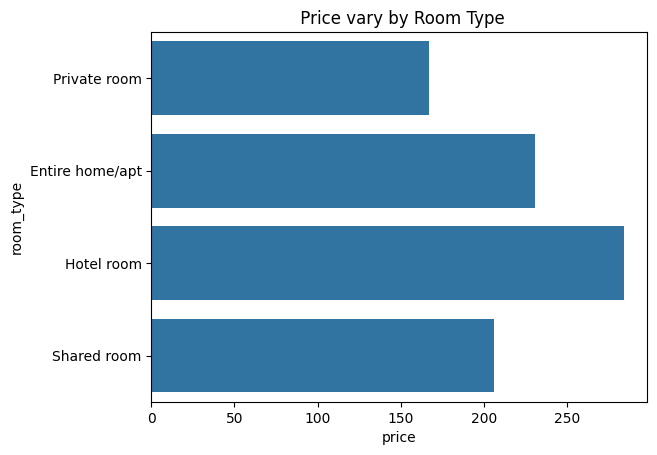

In [ ]:
df.head(1)
sns.barplot(x = df['price'], y = df['room_type'], errorbar=None)
plt.title(' Price vary by Room Type')
plt.show()
# Hotel rooms has the highest price range

**Room type insights**

In [ ]:
# common room type
df['room_type'].value_counts()

# Entire home/apt are the common room type

,count
room_type,
Entire home/apt,5705
Private room,4302
Shared room,129
Hotel room,56


In [ ]:
# expensive room type
df.groupby('room_type')['price'].mean().sort_values(ascending=False)

# hotel rooms are expensive than other rooms

,price
room_type,
Hotel room,284.339286
Entire home/apt,230.992463
Shared room,206.441860
Private room,167.035100


In [ ]:
df['rating'].unique()

array(['5', '4.67', '4.17', '4.64', '4.91', '4.33', '4.5', '4.79',
       'No rating', '4.71', '3.2', '4.8', '4.65', '4.75', '4.89', '4.43',
       '4.82', '4.69', '4.11', '4.9', '4.74', '4.87', '3.67', '4.94',
       '4.66', '4.58', '4.95', '4.78', '4.83', '4.73', '4.53', '4.15',
       '4.45', '4.46', '4.86', '4.42', '4.81', '3.84', '4.27', '4.21',
       '4.93', '4.61', '4.77', '4.4', '4.76', '4.7', '4.6', '4.96',
       '4.56', '3.6', '3', '3.82', '4.92', '4.85', '4', '4.97', '4.63',
       '4.38', '4.72', '4.25', '4.68', '4.99', '4.2', '4.54', '4.88',
       '4.59', '4.57', '4.18', '4.62', 'New ', '4.98', '3.33', '4.29',
       '3.4', '4.44', '4.36', '3.75', '4.22', '4.55', '4.26', '3.92',
       '4.3', '4.12', '4.06', '4.51', '2.33', '4.84', '4.47', '4.39',
       '4.41', '4.35', '3.88', '3.86', '4.07', '4.52', '4.49', '4.23',
       '4.31', '4.13', '3.5', '3.8', '4.32', '3.79', '4.19', '4.16',
       '2.83', '4.48', '3.71', '3.36', '4.14', '3.25', '3.89', '4.1',
       '4.09', '

In [ ]:
# converting string to float values
df['rating']= df['rating'].astype(str)

In [ ]:
# extracting only numbers
df['rating']= df['rating'].str.extract(r"(\d+\.?\d*)")
#changing to numeric column
df['rating'] =  pd.to_numeric(df['rating'], errors='coerce')

In [ ]:
df['rating'].isnull().sum()

np.int64(1880)

In [ ]:
df['rating'].dtype

dtype('float64')

In [ ]:
# filling null values with median
df['rating'].fillna(df['rating'].median(), inplace=True)

/tmp/ipykernel_3278/1221712844.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)


In [ ]:
# ratings for each room type
df.groupby('room_type')['rating'].mean().sort_values(ascending=False)

#so there is slightly differences between room types

,rating
room_type,
Entire home/apt,4.766396
Private room,4.730086
Shared room,4.692403
Hotel room,4.559107


**Location Analysis**

In [ ]:
# top neighbourhoods by average price
# used median because there are outliers
df.groupby('neighbourhood')['price'].median().sort_values(ascending=False)

,price
neighbourhood,
Tribeca,410.5
Woodrow,349.0
Clifton,338.0
Civic Center,306.5
Belle Harbor,300.0
...,...
Manhattan Beach,55.0
Olinville,52.0
Bronxdale,50.0


In [ ]:
# top neighbourhoods by rating
df.groupby('neighbourhood')['rating'].median().sort_values(ascending=False)

,rating
neighbourhood,
Belle Harbor,5.00
Gerritsen Beach,5.00
Columbia St,5.00
Castle Hill,5.00
Rossville,5.00
...,...
Holliswood,4.53
Co-op City,4.51
Mount Eden,4.45


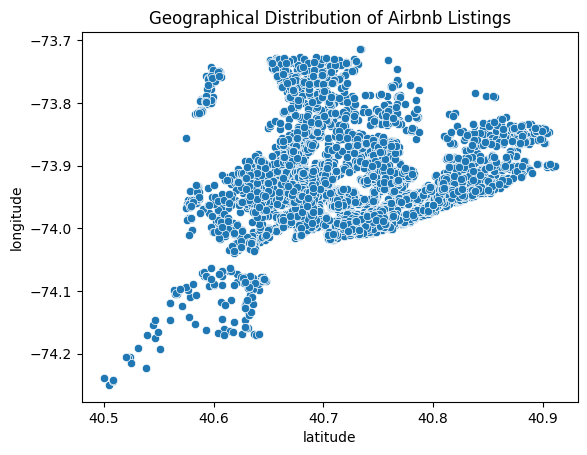

In [ ]:
# geographical distribution
sns.scatterplot(x = df['latitude'], y = df['longitude'])
plt.title('Geographical Distribution of Airbnb Listings')
plt.show()

**Review Analysis**

In [ ]:
# listings with highest reviews
df.groupby('name')['number_of_reviews'].sum().sort_values(ascending=False)

,number_of_reviews
name,
Boutique hotel in New York · ★4.54 · 1 bedroom · 1 bed · 1 private bath,1865
Hotel in New York · ★4.66 · 1 bedroom · 1 bed · 1 private bath,1618
Hotel in New York · ★4.42 · 1 bedroom · 1 bed · 1 private bath,1574
Hotel in New York · ★4.65 · 1 bedroom · 2 beds · 1 shared bath,1201
Townhouse in Brooklyn · ★4.83 · 1 bedroom · 1 bed · 2 shared baths,1196
...,...
Condo in Brooklyn · 3 bedrooms · 3 beds · 3 baths,1
Loft in New York · Studio · 2 beds · 1 bath,1
Home in Brooklyn · 2 bedrooms · 2 beds · 1.5 baths,1


In [ ]:
# relationship between reviews and rating
df['number_of_reviews'].corr(df['rating'])

np.float64(0.0318573111577347)

In [ ]:
# relationship between reviews and price
df['number_of_reviews'].corr(df['price'])

np.float64(-0.011143925270814384)

**Host Analysis**

In [ ]:
# hosts with most listings
df.groupby('host_name')['calculated_host_listings_count'].sum().sort_values(ascending=False)

,calculated_host_listings_count
host_name,
Urban Furnished,30424.0
Eugene,23563.0
Blueground,15686.0
Hiroki,10947.0
Shogo,9960.0
...,...
Zosya,1.0
Zoraida,1.0
Zora & Chris,1.0


In [ ]:
# hosts with average price
df.groupby('host_name')['price'].median().sort_values(ascending=False)

,price
host_name,
Bobbi,100000.0
Rom,10000.0
The Gregory Hotel,10000.0
Aviv,3400.0
Molik,2500.0
...,...
Talib,29.0
Levadieu,27.0
Lakshmee,26.0


**Availability Analysis**

In [ ]:
# listings with most availability
df.groupby('name')['availability_365'].mean().sort_values(ascending=False)

,availability_365
name,
Villa in New York · 1 bedroom · 2 beds · 2 shared baths,365.0
casa particular in The Bronx · ★4.09 · 1 bedroom · 1 bed · 1.5 shared baths,365.0
casa particular in Queens · ★5.0 · 1 bedroom · 1 bed · 1 shared bath,365.0
casa particular in Queens · ★4.90 · 1 bedroom · 1 bed · 1 shared bath,365.0
casa particular in Queens · ★4.62 · 1 bedroom · 1 bed · 1 shared bath,365.0
...,...
Rental unit in New York · ★4.77 · Studio · 1 bed · 1 bath,0.0
Loft in Brooklyn · Studio · 1 bed · 1 bath,0.0
Rental unit in Brooklyn · ★4.41 · 1 bedroom · 1 bed · 1 bath,0.0


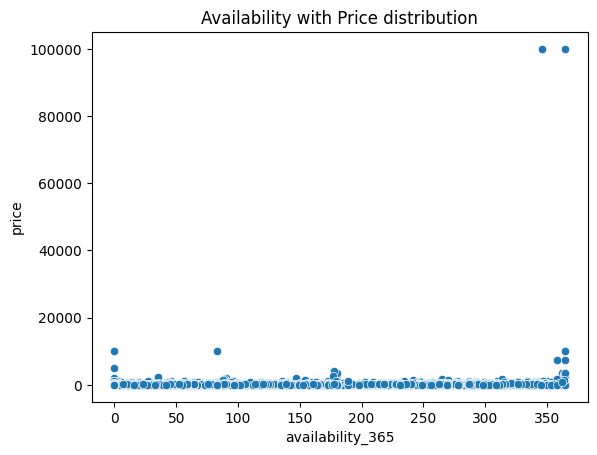

In [ ]:
# availability vs price
sns.scatterplot(x = df['availability_365'], y = df['price'])
plt.title('Availability with Price distribution')
plt.show()

**Property Features**

In [ ]:
# how price affects bedrooms
df.groupby('bedrooms')['price'].median().sort_values(ascending=False)

,price
bedrooms,
15,1815.0
8,1596.0
9,832.0
6,700.0
7,644.0
5,370.5
4,350.0
3,250.0
2,185.0


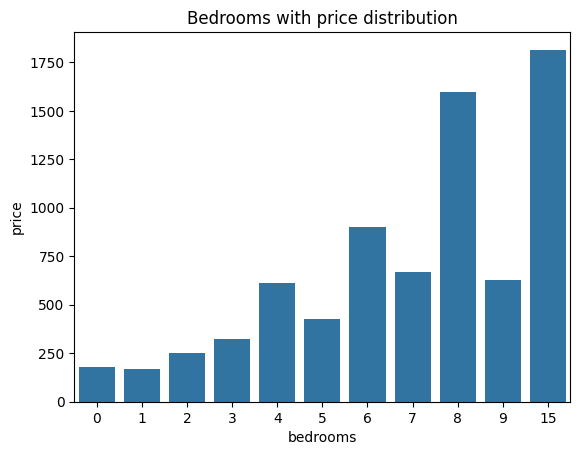

In [ ]:
sns.barplot(x = df['bedrooms'], y = df['price'], errorbar=None)
plt.title('Bedrooms with price distribution')
plt.show()

In [ ]:
# how beds affects prices
df.groupby('beds')['price'].median().sort_values(ascending=False)

,price
beds,
21.0,1815.0
9.0,877.0
11.0,832.0
12.0,756.0
8.0,490.0
7.0,374.5
6.0,330.0
10.0,325.0
5.0,268.5


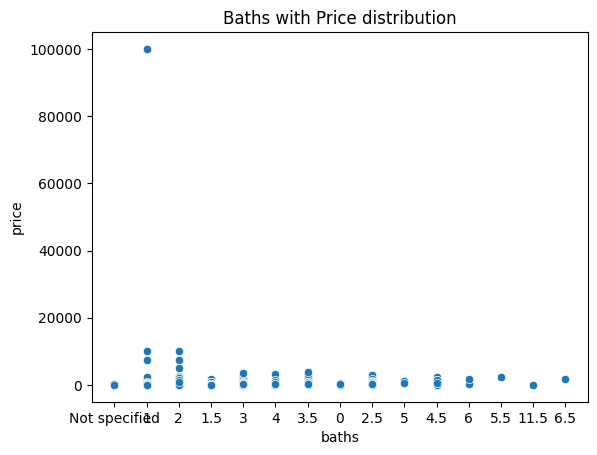

In [ ]:
# how baths affects prices
sns.scatterplot(x = df['baths'], y = df['price'])
plt.title('Baths with Price distribution')
plt.show()

**Anomaly Detection**

In [ ]:
df['minimum_nights'].describe()
# max is very high

,minimum_nights
count,10192.000000
mean,29.116170
std,39.725563
min,1.000000
25%,30.000000
50%,30.000000
75%,30.000000
max,1250.000000


In [ ]:
df['rating'].isnull().sum()

np.int64(0)

**Correlation**

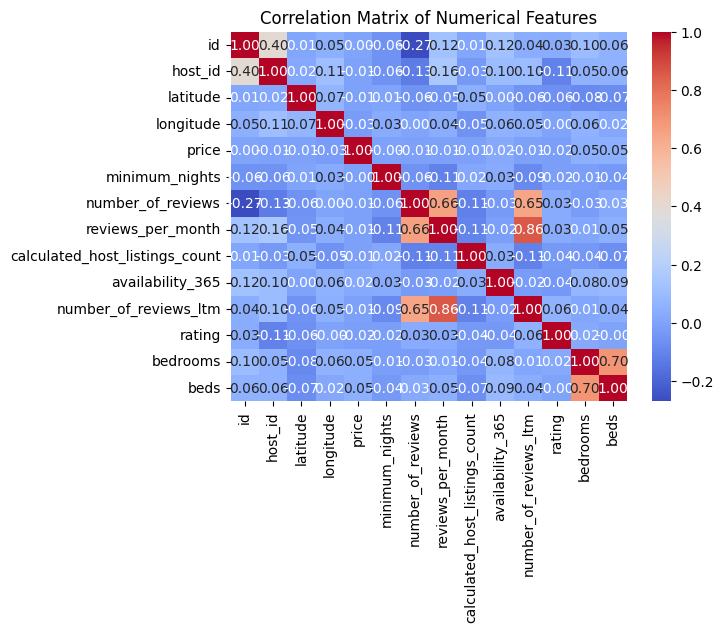

In [ ]:
# correlation between all the columns
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# **Feature Engineering**

In [ ]:
# price category
def price(num):
  if num >= 100:
    return 'Budget'
  elif num > 500 :
    return 'Moderate'
  elif num > 1000:
    return 'Premium'
  else:
    return 'Luxury'

df['price_category'] = df['price'].apply(price)

In [ ]:
# stay category
df['stay_type'] = df['minimum_nights'].apply(lambda x : "Short" if x <= 3 else 'Medium' if x <= 10 else 'Long')

In [ ]:
# host type
df['host_type'] = df['calculated_host_listings_count'].apply(lambda x : 'Individual' if x == 1 else 'Professional')

In [ ]:
# availability category
def category(num):
  if num <= 50:
    return 'Low'
  elif num <= 150:
    return 'Medium'
  else:
    return 'High'

df['availability_level'] = df['availability_365'].apply(category)

In [ ]:
# review activity
df['review_activity'] = df['reviews_per_month'].apply(lambda x : 'Inactive' if x == 0 else "Active")

In [ ]:
df['price_per_beds'] = df['price'] / df['beds']

In [ ]:
df['review_intensity'] = df['number_of_reviews'] / (df['availability_365']+1)

**Visualizations using New Features**

Text(0.5, 1.0, 'Price Distribution by Room type and Host type')

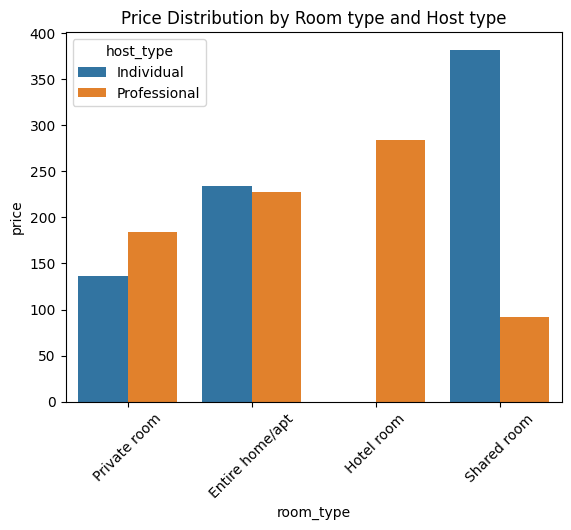

In [ ]:
sns.barplot(x='room_type', y = 'price', hue = 'host_type', data=df, errorbar=None)
plt.xticks(rotation=45)
plt.title('Price Distribution by Room type and Host type')

# for shared rooms individual price is high but for other professional charges more

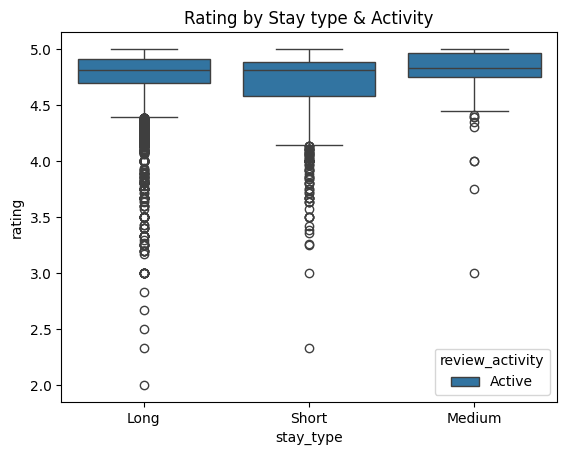

In [ ]:
# rating vs stay type and review activity
sns.boxplot(x='stay_type', y='rating', hue='review_activity', data=df)
plt.title('Rating by Stay type & Activity')
plt.show()


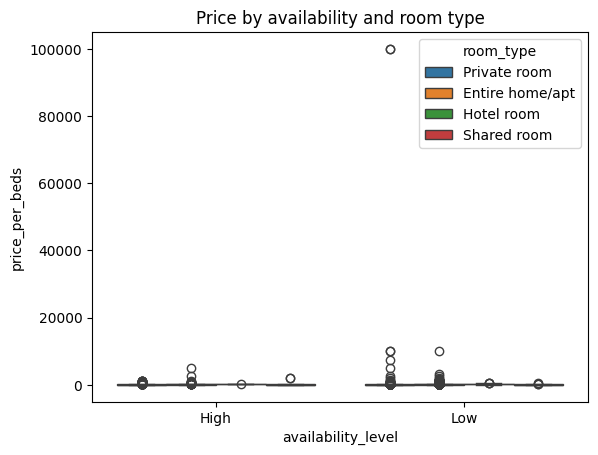

In [ ]:
# price per bed vs availability level
sns.boxplot(x='availability_level', y = 'price_per_beds', hue = 'room_type', data=df)
plt.title('Price by availability and room type')
plt.show()

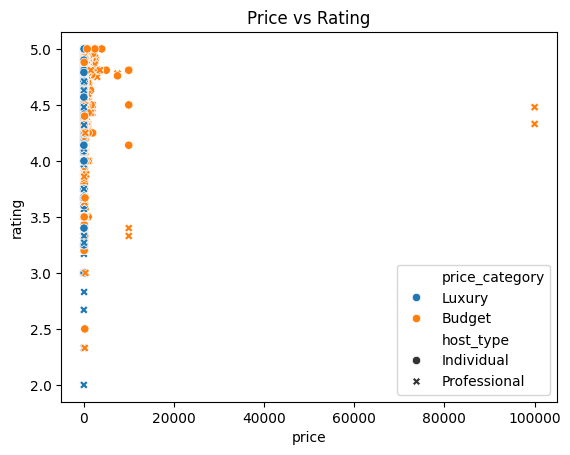

In [ ]:
sns.scatterplot(
    x = 'price',
    y = 'rating',
    hue='price_category',
    style='host_type',
    data = df
)
plt.title('Price vs Rating')
plt.show()

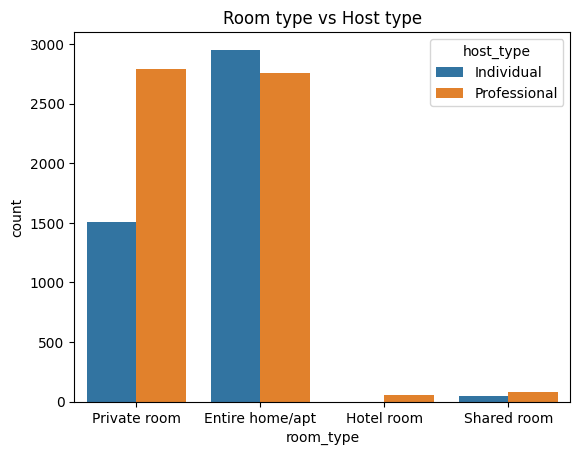

In [ ]:
# market composition
sns.countplot(x='room_type', hue='host_type', data=df)
plt.title('Room type vs Host type')
plt.show()

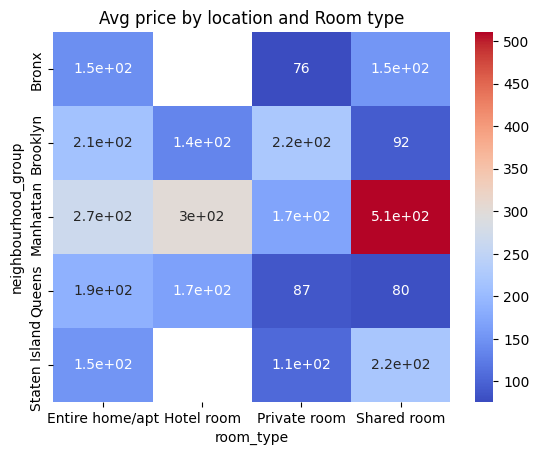

In [ ]:
pivot = df.pivot_table(
    values = 'price',
    index = 'neighbourhood_group',
    columns = 'room_type',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Avg price by location and Room type')
plt.show()

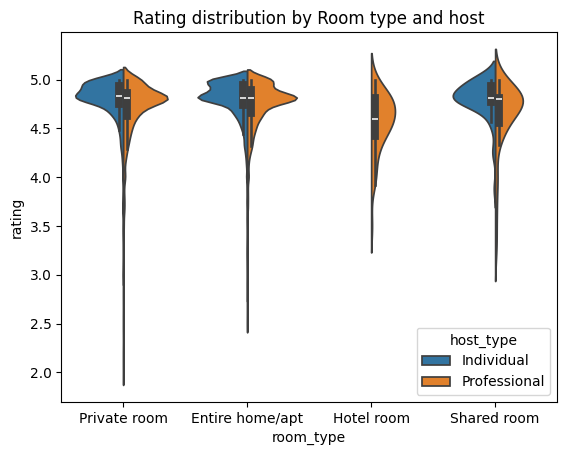

In [ ]:
sns.violinplot(x='room_type', y='rating', hue='host_type', data=df, split=True)
plt.title('Rating distribution by Room type and host')
plt.show()

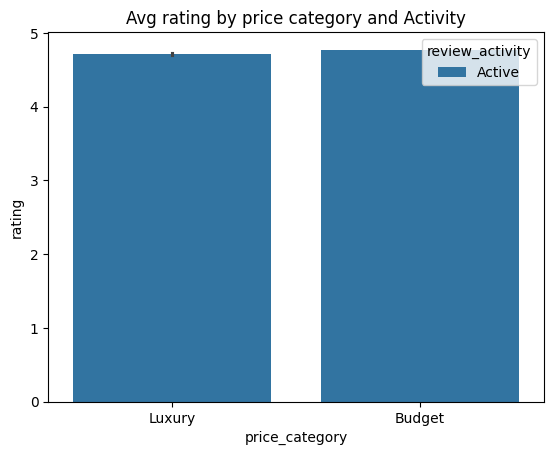

In [ ]:
sns.barplot(
    x = 'price_category',
    y = 'rating',
    hue='review_activity',
    data=df
)
plt.title('Avg rating by price category and Activity')
plt.show()

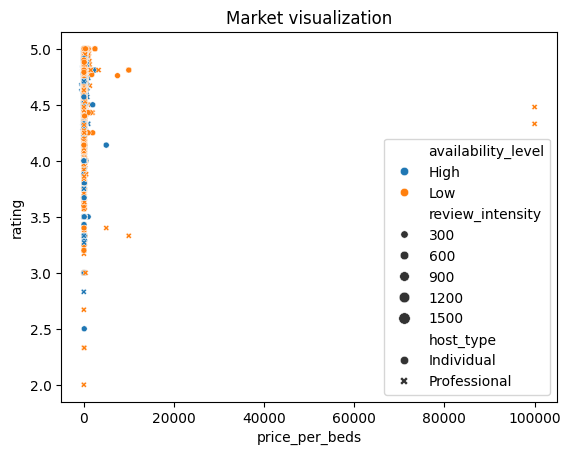

In [ ]:
sns.scatterplot(
    x = 'price_per_beds',
    y = 'rating',
    hue='availability_level',
    style='host_type',
    size='review_intensity',
    data=df
)
plt.title('Market visualization')
plt.show()